### Web Scraping

In [2]:
import requests
import time
import re
import pandas as pd
from bs4 import BeautifulSoup
from urllib.parse import urljoin

BASE_URL = "https://books.toscrape.com/"
CATALOGUE_URL = BASE_URL + "catalogue/"

RATING_MAP = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

def get_book_links():
    book_links = []
    page_url = CATALOGUE_URL + "page-1.html"

    while True:
        print(f"Scraping listing page: {page_url}")
        res = requests.get(page_url, timeout=10)
        soup = BeautifulSoup(res.text, "html.parser")

        books = soup.select("article.product_pod h3 a")
        for book in books:
            link = book.get("href")
            full_link = urljoin(CATALOGUE_URL, link)
            book_links.append(full_link)

        next_btn = soup.select_one("li.next a")
        if not next_btn:
            break

        page_url = urljoin(page_url, next_btn.get("href"))
        time.sleep(1)

    return book_links

def scrape_book_details(url):
    res = requests.get(url, timeout=10)
    soup = BeautifulSoup(res.text, "html.parser")

    title = soup.find("h1").text.strip()

    price_text = soup.select_one("p.price_color").text
    price = float(re.sub(r"[^\d.]", "", price_text))


    rating_class = soup.select_one("p.star-rating")["class"][1]
    rating = RATING_MAP.get(rating_class)

    availability_text = soup.select_one("p.availability").text.strip()
    stock_match = re.search(r"\d+", availability_text)
    stock_count = int(stock_match.group()) if stock_match else 0

    description_tag = soup.select_one("#product_description")
    description = (
        description_tag.find_next_sibling("p").text.strip()
        if description_tag else None
    )

    category = soup.select("ul.breadcrumb li a")[-1].text.strip()

    table = soup.find("table", class_="table table-striped")
    metadata = {
        row.th.text.strip(): row.td.text.strip()
        for row in table.find_all("tr")
    }

    return {
        "book_id": metadata.get("UPC"),
        "title": title,
        "category": category,
        "price": price,
        "rating": rating,
        "availability_text": availability_text,
        "stock_count": stock_count,
        "product_description": description,
        "upc": metadata.get("UPC"),
        "product_url": url
    }

def run_scraper():
    links = get_book_links()
    print(f"\nTotal books found: {len(links)}\n")

    data = []
    for i, link in enumerate(links, start=1):
        try:
            book = scrape_book_details(link)
            data.append(book)
            print(f"[{i}/{len(links)}] Scraped: {book['title']}")
            time.sleep(0.5)
        except Exception as e:
            print(f"[FAILED] {link} | {e}")

    df = pd.DataFrame(data)
    df.drop_duplicates(subset="upc", inplace=True)
    df.to_csv("raw_books.csv", index=False)
    print("\nSaved raw_books.csv")

if __name__ == "__main__":
    run_scraper()


Scraping listing page: https://books.toscrape.com/catalogue/page-1.html
Scraping listing page: https://books.toscrape.com/catalogue/page-2.html
Scraping listing page: https://books.toscrape.com/catalogue/page-3.html
Scraping listing page: https://books.toscrape.com/catalogue/page-4.html
Scraping listing page: https://books.toscrape.com/catalogue/page-5.html
Scraping listing page: https://books.toscrape.com/catalogue/page-6.html
Scraping listing page: https://books.toscrape.com/catalogue/page-7.html


KeyboardInterrupt: 

## Data Understanding

In [73]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

books = pd.read_csv('raw_books.csv')
books

,book_id,title,category,price,rating,availability_text,stock_count,product_description,upc,product_url
0,a897fe39b1053632,A Light in the Attic,Poetry,51.77,3,In stock (22 available),22,It's hard to imagine a world without A Light i...,a897fe39b1053632,https://books.toscrape.com/catalogue/a-light-i...
1,90fa61229261140a,Tipping the Velvet,Historical Fiction,53.74,1,In stock (20 available),20,"""Erotic and absorbing...Written with starling ...",90fa61229261140a,https://books.toscrape.com/catalogue/tipping-t...
2,6957f44c3847a760,Soumission,Fiction,50.10,1,In stock (20 available),20,"Dans une France assez proche de la nÃ´tre, un ...",6957f44c3847a760,https://books.toscrape.com/catalogue/soumissio...
3,e00eb4fd7b871a48,Sharp Objects,Mystery,47.82,4,In stock (20 available),20,"WICKED above her hipbone, GIRL across her hear...",e00eb4fd7b871a48,https://books.toscrape.com/catalogue/sharp-obj...
4,4165285e1663650f,Sapiens: A Brief History of Humankind,History,54.23,5,In stock (20 available),20,From a renowned historian comes a groundbreaki...,4165285e1663650f,https://books.toscrape.com/catalogue/sapiens-a...
...,...,...,...,...,...,...,...,...,...,...
988,cd2a2a70dd5d176d,Alice in Wonderland (Alice's Adventures in Won...,Classics,55.53,1,In stock (1 available),1,NaN,cd2a2a70dd5d176d,https://books.toscrape.com/catalogue/alice-in-...
989,bfd5e1701c862ac3,"Ajin: Demi-Human, Volume 1 (Ajin: Demi-Human #1)",Sequential Art,57.06,4,In stock (1 available),1,High school student Kei Nagai is struck dead i...,bfd5e1701c862ac3,https://books.toscrape.com/catalogue/ajin-demi...
990,19fec36a1dfb4c16,A Spy's Devotion (The Regency Spies of London #1),Historical Fiction,16.97,5,In stock (1 available),1,"In Englandâs Regency era, manners and elegan...",19fec36a1dfb4c16,https://books.toscrape.com/catalogue/a-spys-de...
991,f684a82adc49f011,1st to Die (Women's Murder Club #1),Mystery,53.98,1,In stock (1 available),1,"James Patterson, bestselling author of the Ale...",f684a82adc49f011,https://books.toscrape.com/catalogue/1st-to-di...


In [75]:
books.shape

(993, 10)

In [76]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   book_id              993 non-null    object 
 1   title                993 non-null    object 
 2   category             993 non-null    object 
 3   price                993 non-null    float64
 4   rating               993 non-null    int64  
 5   availability_text    993 non-null    object 
 6   stock_count          993 non-null    int64  
 7   product_description  991 non-null    object 
 8   upc                  993 non-null    object 
 9   product_url          993 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 77.7+ KB


In [77]:
books.describe()

,price,rating,stock_count
count,993.000000,993.000000,993.000000
mean,35.115932,2.920443,8.591138
std,14.407230,1.433582,5.656320
min,10.010000,1.000000,1.000000
25%,22.130000,2.000000,3.000000
50%,36.050000,3.000000,7.000000
75%,47.440000,4.000000,14.000000
max,59.990000,5.000000,22.000000


In [78]:
books.nunique()

book_id                993
title                  992
category                50
price                  897
rating                   5
availability_text       21
stock_count             21
product_description    991
upc                    993
product_url            993
dtype: int64

In [79]:
books.isnull().sum()

book_id                0
title                  0
category               0
price                  0
rating                 0
availability_text      0
stock_count            0
product_description    2
upc                    0
product_url            0
dtype: int64

In [80]:
books.duplicated().sum()

np.int64(0)

## Data Cleaning

In [81]:
books["stock_capped"] = books["stock_count"].clip(upper=20)
books["demand_score"] = books["rating"] * books["stock_capped"]

In [82]:
threshold = books["demand_score"].quantile(0.75)
books["high_demand"] = (books["demand_score"] >= threshold).astype(int)

In [83]:
books = books.drop('availability_text', axis = 1)

In [84]:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 993 entries, 0 to 992
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   book_id              993 non-null    object 
 1   title                993 non-null    object 
 2   category             993 non-null    object 
 3   price                993 non-null    float64
 4   rating               993 non-null    int64  
 5   stock_count          993 non-null    int64  
 6   product_description  991 non-null    object 
 7   upc                  993 non-null    object 
 8   product_url          993 non-null    object 
 9   stock_capped         993 non-null    int64  
 10  demand_score         993 non-null    int64  
 11  high_demand          993 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 93.2+ KB


Lower Bound: -15.834999999999997
Upper Bound: 85.405
Outliers Detected : 
Empty DataFrame
Columns: [book_id, title, category, price, rating, stock_count, product_description, upc, product_url, stock_capped, demand_score, high_demand]
Index: []


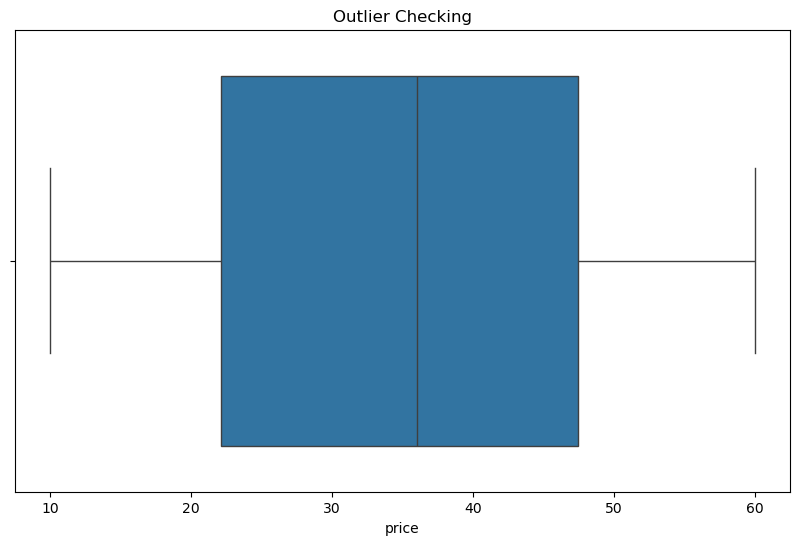

In [89]:
import seaborn as sns

Q1 = books['price'].quantile(0.25)
Q3 = books['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = books[(books['price'] < lower_bound) | (books['price'] > upper_bound)]

print(f'Lower Bound: {lower_bound}')
print(f'Upper Bound: {upper_bound}')
print(f'Outliers Detected : \n{outliers}')

plt.figure(figsize = (10,6))
sns.boxplot(x=books['price'])
plt.title('Outlier Checking')
plt.show()

Lower Bound: -1.0
Upper Bound: 7.0
Outliers Detected : 
Empty DataFrame
Columns: [book_id, title, category, price, rating, stock_count, product_description, upc, product_url, stock_capped, demand_score, high_demand]
Index: []


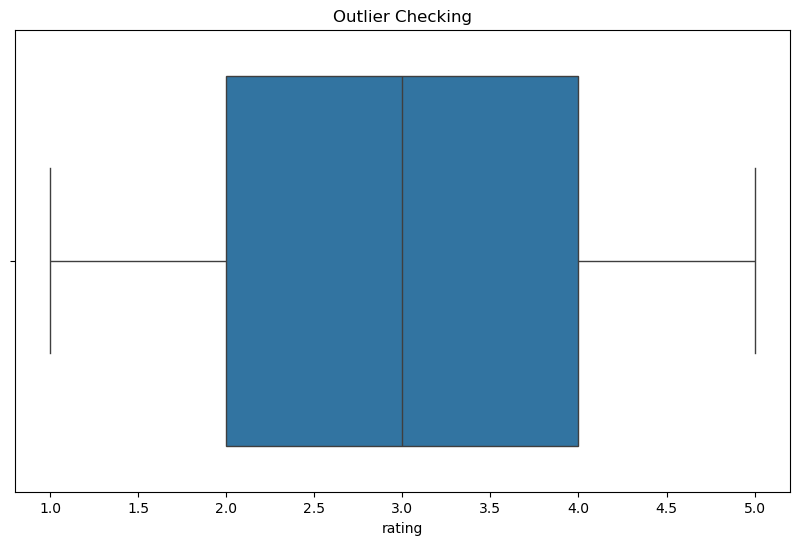

In [90]:
Q1 = books['rating'].quantile(0.25)
Q3 = books['rating'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = books[(books['rating'] < lower_bound) | (books['rating'] > upper_bound)]

print(f'Lower Bound: {lower_bound}')
print(f'Upper Bound: {upper_bound}')
print(f'Outliers Detected : \n{outliers}')

plt.figure(figsize = (10,6))
sns.boxplot(x=books['rating'])
plt.title('Outlier Checking')
plt.show()

Lower Bound: -13.5
Upper Bound: 30.5
Outliers Detected : 
Empty DataFrame
Columns: [book_id, title, category, price, rating, stock_count, product_description, upc, product_url, stock_capped, demand_score, high_demand]
Index: []


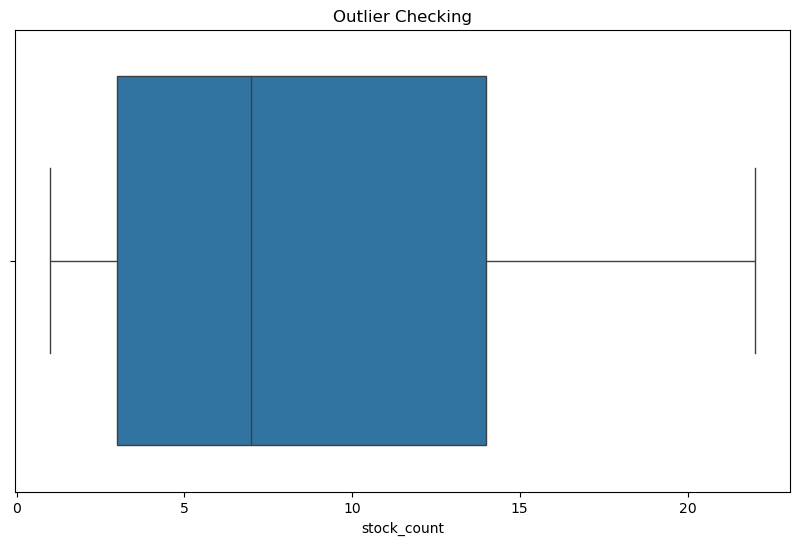

In [88]:
Q1 = books['stock_count'].quantile(0.25)
Q3 = books['stock_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = books[(books['stock_count'] < lower_bound) | (books['stock_count'] > upper_bound)]

print(f'Lower Bound: {lower_bound}')
print(f'Upper Bound: {upper_bound}')
print(f'Outliers Detected : \n{outliers}')

plt.figure(figsize = (10,6))
sns.boxplot(x=books['stock_count'])
plt.title('Outlier Checking')
plt.show()

In [114]:
books.to_csv('cleaned_books.csv', index=False)
print('file saved succesfully')

file saved succesfully


## Statistical Testing

In [115]:
df = pd.read_csv('cleaned_books.csv')

from scipy.stats import spearmanr, mannwhitneyu

print("TEST 1: Price vs Demand Score")

corr, p = spearmanr(df["price"], df["demand_score"])
print(f"Spearman correlation: {corr:.4f}")
print(f"P-value: {p:.4e}")
if p < 0.05:
    print(f'Failed to reject null hypothesis: Price and Demand_score are not related')
else:
    print(f'Reject null hypothesis: Price and Demand_score are related')

TEST 1: Price vs Demand Score
Spearman correlation: 0.0090
P-value: 7.7645e-01
Reject null hypothesis: Price and Demand_score are related


In [116]:
print("TEST 2: Price Distribution (High vs Low Demand)")

high = df[df["high_demand"] == 1]["price"]
low = df[df["high_demand"] == 0]["price"]

u_stat, p = mannwhitneyu(high, low, alternative="two-sided")
print(f"U statistic: {u_stat:.2f}")
print(f"P-value: {p:.4e}")
if p < 0.05:
    print(f'Failed to reject null hypothesis: High-demand and Low-demand books have the same price distribution')
else:
    print(f'Reject null hypothesis: High-demand and Low-demand books have diferent price distribution')

TEST 2: Price Distribution (High vs Low Demand)
U statistic: 97489.00
P-value: 5.3938e-01
Reject null hypothesis: High-demand and Low-demand books have diferent price distribution


## Visualization

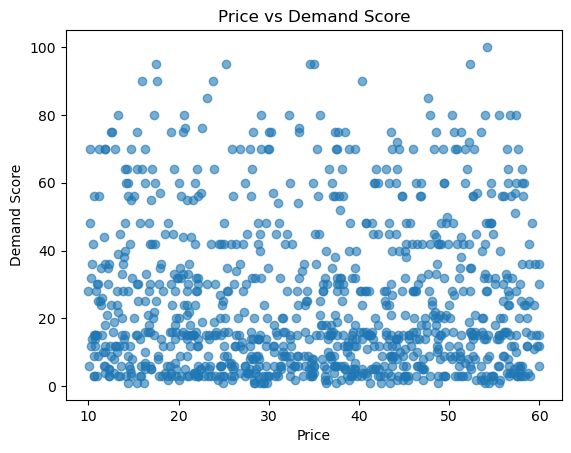

In [117]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(df["price"], df["demand_score"], alpha=0.6)
plt.xlabel("Price")
plt.ylabel("Demand Score")
plt.title("Price vs Demand Score")
plt.show()

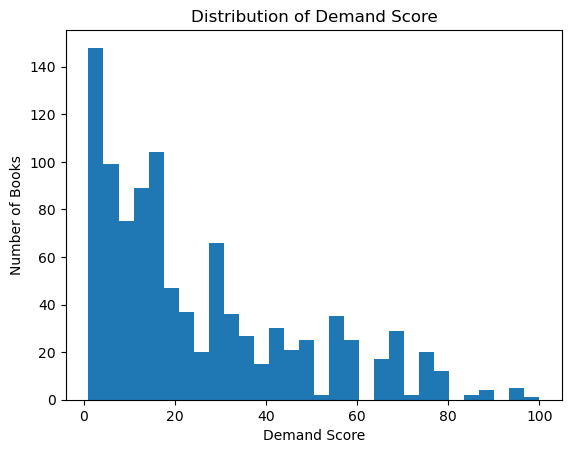

In [118]:
plt.figure()
plt.hist(df["demand_score"], bins=30)
plt.xlabel("Demand Score")
plt.ylabel("Number of Books")
plt.title("Distribution of Demand Score")
plt.show()

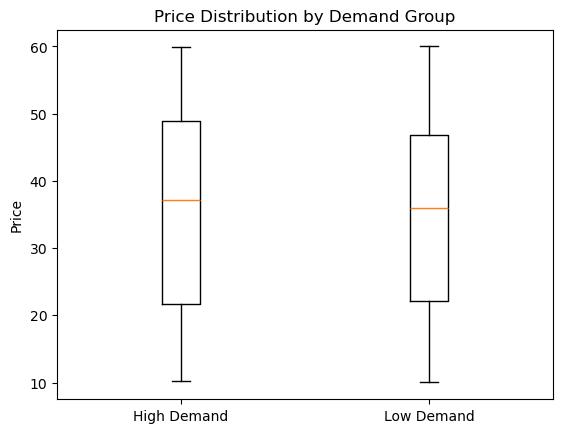

In [119]:
plt.figure()
plt.boxplot(
    [df[df["high_demand"] == 1]["price"],
     df[df["high_demand"] == 0]["price"]],
    labels=["High Demand", "Low Demand"]
)
plt.ylabel("Price")
plt.title("Price Distribution by Demand Group")
plt.show()

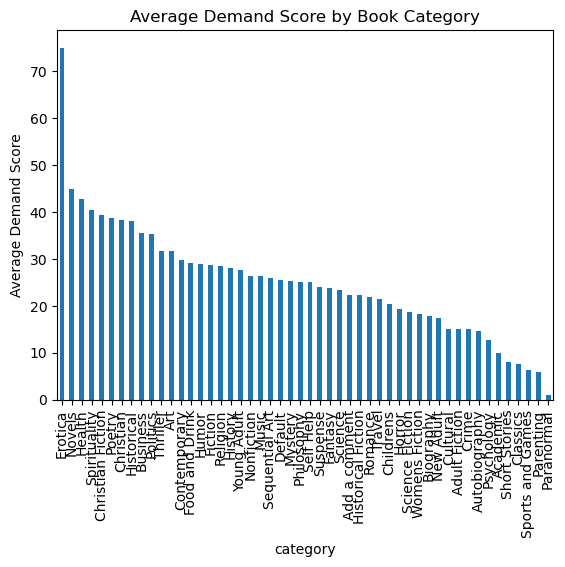

In [121]:
category_demand = df.groupby("category")["demand_score"].mean().sort_values(ascending=False)

plt.figure()
category_demand.plot(kind="bar")
plt.ylabel("Average Demand Score")
plt.title("Average Demand Score by Book Category")
plt.show()

## Data storing

In [34]:
pip install sqlalchemy pandas

In [122]:
print(df.shape)
df.head()

(993, 12)


,book_id,title,category,price,rating,stock_count,product_description,upc,product_url,stock_capped,demand_score,high_demand
0,a897fe39b1053632,A Light in the Attic,Poetry,51.77,3,22,It's hard to imagine a world without A Light i...,a897fe39b1053632,https://books.toscrape.com/catalogue/a-light-i...,20,60,1
1,90fa61229261140a,Tipping the Velvet,Historical Fiction,53.74,1,20,"""Erotic and absorbing...Written with starling ...",90fa61229261140a,https://books.toscrape.com/catalogue/tipping-t...,20,20,0
2,6957f44c3847a760,Soumission,Fiction,50.10,1,20,"Dans une France assez proche de la nÃ´tre, un ...",6957f44c3847a760,https://books.toscrape.com/catalogue/soumissio...,20,20,0
3,e00eb4fd7b871a48,Sharp Objects,Mystery,47.82,4,20,"WICKED above her hipbone, GIRL across her hear...",e00eb4fd7b871a48,https://books.toscrape.com/catalogue/sharp-obj...,20,80,1
4,4165285e1663650f,Sapiens: A Brief History of Humankind,History,54.23,5,20,From a renowned historian comes a groundbreaki...,4165285e1663650f,https://books.toscrape.com/catalogue/sapiens-a...,20,100,1


In [123]:
from sqlalchemy import create_engine

engine = create_engine("sqlite:///books.db")

df.to_sql(
    "books",
    engine,
    if_exists="replace",
    index=False
)

993

In [124]:
pd.read_sql("""
SELECT COUNT(*) AS rows FROM books;
""", engine)

,rows
0,993


## Unsupervised

In [125]:
df_db = pd.read_sql("""
SELECT
    book_id,
    price,
    rating,
    stock_capped,
    demand_score
FROM books
""", engine)

print(df_db.shape)

(993, 5)


In [126]:
features = ["price", "rating", "stock_capped", "demand_score"]
X = df_db[features]

In [127]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [128]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_db["cluster"] = kmeans.fit_predict(X_scaled)

In [129]:
df_db["cluster"].value_counts()

cluster
2    299
0    262
3    225
1    207
Name: count, dtype: int64

In [131]:
from sqlalchemy import text

with engine.connect() as conn:
    conn.execute(text("""
        ALTER TABLE books
        ADD COLUMN cluster INTEGER
    """))
    conn.commit()

In [132]:
pd.read_sql("""
PRAGMA table_info(books);
""", engine)

,cid,name,type,notnull,dflt_value,pk
0,0,book_id,TEXT,0,None,0
1,1,title,TEXT,0,None,0
2,2,category,TEXT,0,None,0
3,3,price,FLOAT,0,None,0
4,4,rating,BIGINT,0,None,0
5,5,stock_count,BIGINT,0,None,0
6,6,product_description,TEXT,0,None,0
7,7,upc,TEXT,0,None,0
8,8,product_url,TEXT,0,None,0
9,9,stock_capped,BIGINT,0,None,0


In [133]:
from sqlalchemy.orm import Session
from sqlalchemy import text

with Session(engine) as session:
    for _, row in df_db[["book_id", "cluster"]].iterrows():
        session.execute(
            text("""
                UPDATE books
                SET cluster = :cluster
                WHERE book_id = :book_id
            """),
            {
                "cluster": int(row.cluster),
                "book_id": row.book_id
            }
        )
    session.commit()

In [134]:
pd.read_sql("""
SELECT cluster, COUNT(*) AS count
FROM books
GROUP BY cluster
""", engine)

,cluster,count
0,0,262
1,1,207
2,2,299
3,3,225


## Supervised 

In [135]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine("sqlite:///books.db")

df = pd.read_sql("""
SELECT
    price,
    rating,
    stock_capped,
    cluster,
    high_demand
FROM books
WHERE high_demand IS NOT NULL
""", engine)

df.head()

,price,rating,stock_capped,cluster,high_demand
0,51.77,3,20,1,1
1,53.74,1,20,3,0
2,50.10,1,20,3,0
3,47.82,4,20,1,1
4,54.23,5,20,1,1


In [136]:
X = df[["price", "rating", "stock_capped", "cluster"]]
y = df["high_demand"]

In [137]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [138]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

log_reg.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [139]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_lr = log_reg.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       220
           1       0.93      0.95      0.94        78

    accuracy                           0.97       298
   macro avg       0.95      0.96      0.96       298
weighted avg       0.97      0.97      0.97       298

[[214   6]
 [  4  74]]


In [140]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [141]:
y_pred_rf = rf.predict(X_test)

print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       220
           1       1.00      0.99      0.99        78

    accuracy                           1.00       298
   macro avg       1.00      0.99      1.00       298
weighted avg       1.00      1.00      1.00       298

[[220   0]
 [  1  77]]


In [142]:
import pandas as pd

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

stock_capped    0.509556
rating          0.299874
cluster         0.164025
price           0.026546
dtype: float64

In [143]:
X_no_cluster = df[["price", "rating", "stock_capped"]]

X_train_nc, X_test_nc, y_train_nc, y_test_nc = train_test_split(
    X_no_cluster,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

rf_nc = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_nc.fit(X_train_nc, y_train_nc)
y_pred_nc = rf_nc.predict(X_test_nc)

print(classification_report(y_test_nc, y_pred_nc))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       220
           1       1.00      0.99      0.99        78

    accuracy                           1.00       298
   macro avg       1.00      0.99      1.00       298
weighted avg       1.00      1.00      1.00       298



In [144]:
from sklearn.metrics import accuracy_score

train_acc = accuracy_score(y_train, rf.predict(X_train))
test_acc = accuracy_score(y_test, rf.predict(X_test))

train_acc, test_acc

(1.0, 0.9966442953020134)

In [145]:
X_nocluster = df[["price", "rating", "stock_capped"]]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_nocluster, y, test_size=0.3, stratify=y, random_state=42
)

rf_nc = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_nc.fit(X_tr, y_tr)
accuracy_score(y_te, rf_nc.predict(X_te))

0.9966442953020134